#**Análisis de Sentimiento sobre Reseñas de Clientes de FastBurger BA**

#Contexto del proyecto

FastBurger BA es una cadena de comida rápida con presencia en distintas sucursales de la Ciudad de Buenos Aires.

El crecimiento sostenido en la cantidad de opiniones generadas por los clientes plantea la necesidad de desarrollar herramientas que permitan comprender de forma rápida y escalable la percepción del servicio.

El objetivo general de este proyecto es construir un sistema capaz de clasificar automáticamente el sentimiento asociado a una reseña utilizando técnicas de Procesamiento de Lenguaje Natural y Deep Learning.

En esta primera iteración se construye la infraestructura base de entrenamiento y validación que servirá de fundamento para las siguientes etapas del proyecto.

💡 Este notebook está pensado para ejecutarse en Google Colab o en cualquier entorno local con Python 3.10+ y PyTorch instalado.

In [16]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score

## Inicialización del proyecto

Se configura un entorno reproducible y compatible con distintos tipos de hardware, logrando que se identifique automáticamente el dispositivo disponible para entrenamiento.

Para ello se fijan semillas de aleatoriedad y se detecta automáticamente el dispositivo de cómputo disponible (CPU, GPU NVIDIA o Apple Silicon).

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")

elif torch.backends.mps.is_available():
    device = torch.device("mps")

else:
    device = torch.device("cpu")

print(f"Dispositivo utilizado: {device}")
print(f"Versión de PyTorch: {torch.__version__}")

Dispositivo utilizado: cpu
Versión de PyTorch: 2.11.0+cpu


## Carga de la fuente de datos

La fuente de información utilizada corresponde a opiniones de clientes de distintas sucursales de FastBurger BA.

El archivo se encuentra almacenado en Google Drive y contiene reseñas textuales junto con variables asociadas a la experiencia del cliente, como sucursal, barrio, canal de compra, rating, sentimiento y tema principal.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
ruta_archivo = "/content/drive/MyDrive/Data Science/Opiniones_Cadena_Hamburguesas.xlsx"

df = pd.read_excel(
    ruta_archivo,
    engine="openpyxl"
)

print(f"Filas: {df.shape,}")
print(f"Columnas: {df.shape[1]}")

df.head()

Filas: ((50000, 10),)
Columnas: 10


,id_resena,cadena,sucursal,barrio,fecha_resena,canal,resena_bruta,rating,sentimiento,tema_principal
0,1,FastBurger BA,Dot Baires Shopping,Saavedra,2026-06-01,takeaway,La experiencia fue excelente. entrega bastante...,4,positivo,tiempo_entrega
1,2,FastBurger BA,Abasto Shopping,Abasto,2026-02-26,takeaway,NUNCA LLEGA EL PEDIDO PFFF 🤦 fatal,1,negativo,tiempo_entrega
2,3,FastBurger BA,Alto Palermo,Palermo,2026-01-24,takeaway,cobertura intermitente 🔥,3,neutro,cobertura_zona
3,4,FastBurger BA,Dot Baires Shopping,Saavedra,2026-01-21,mostrador,no llega a mi barrio fatal,1,negativo,cobertura_zona
4,5,FastBurger BA,Alto Avellaneda,Avellaneda,2026-01-21,delivery_app,se congela mientras pido 👍 meh,2,negativo,usabilidad_app


## Comprensión inicial de los datos

Antes de iniciar el modelado realizaremos una revisión de la estructura general del dataset.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id_resena       50000 non-null  int64 
 1   cadena          50000 non-null  object
 2   sucursal        50000 non-null  object
 3   barrio          50000 non-null  object
 4   fecha_resena    50000 non-null  object
 5   canal           50000 non-null  object
 6   resena_bruta    50000 non-null  object
 7   rating          50000 non-null  int64 
 8   sentimiento     50000 non-null  object
 9   tema_principal  50000 non-null  object
dtypes: int64(2), object(8)
memory usage: 3.8+ MB


In [6]:
df.head(3)

,id_resena,cadena,sucursal,barrio,fecha_resena,canal,resena_bruta,rating,sentimiento,tema_principal
0,1,FastBurger BA,Dot Baires Shopping,Saavedra,2026-06-01,takeaway,La experiencia fue excelente. entrega bastante...,4,positivo,tiempo_entrega
1,2,FastBurger BA,Abasto Shopping,Abasto,2026-02-26,takeaway,NUNCA LLEGA EL PEDIDO PFFF 🤦 fatal,1,negativo,tiempo_entrega
2,3,FastBurger BA,Alto Palermo,Palermo,2026-01-24,takeaway,cobertura intermitente 🔥,3,neutro,cobertura_zona


In [7]:
df["sentimiento"].value_counts()

,count
sentimiento,
positivo,20096
negativo,19987
neutro,9917


In [8]:
df["sentimiento"].value_counts(normalize=True) * 100

,proportion
sentimiento,
positivo,40.192
negativo,39.974
neutro,19.834


## Estado inicial del problema

Antes de iniciar el entrenamiento resulta útil comprender cuántas observaciones pertenecen a cada categoría de sentimiento.

Esta distribución servirá como referencia para interpretar posteriormente las métricas obtenidas por el modelo.

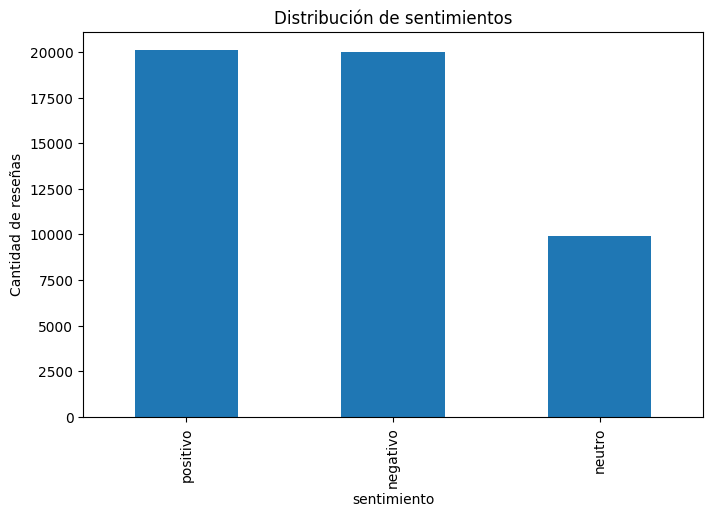

In [31]:
plt.figure(figsize=(8,5))

df["sentimiento"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Distribución de sentimientos"
)

plt.ylabel(
    "Cantidad de reseñas"
)

plt.show()

### Observaciones iniciales

La distribución de sentimientos muestra una presencia importante de las categorías positiva y negativa, mientras que las opiniones neutras aparecen en menor proporción.

Si bien no existe un desbalance extremo que impida el entrenamiento del modelo, esta diferencia deberá tenerse en cuenta al momento de interpretar las métricas obtenidas.

En esta primera etapa se considera que la distribución disponible es suficiente para construir una línea base de clasificación y validar el funcionamiento del pipeline.

## Preparación inicial del dataset

Para entrenar el modelo en PyTorch es necesario transformar la variable de sentimiento en una representación numérica.

La codificación utilizada será:

- negativo: 0
- neutro: 1
- positivo: 2

En esta primera iteración se trabajará con la reseña original como entrada del modelo, aplicando una limpieza ligera del texto.

In [32]:
df["label_sentimiento"] = (
    df["sentimiento"]
    .map({
        "negativo": 0,
        "neutro": 1,
        "positivo": 2
    })
)

df[["sentimiento", "label_sentimiento"]].head()

,sentimiento,label_sentimiento
0,positivo,2
1,negativo,0
2,neutro,1
3,negativo,0
4,negativo,0


In [10]:
df[["resena_bruta", "sentimiento", "label_sentimiento", "tema_principal"]].head()

,resena_bruta,sentimiento,label_sentimiento,tema_principal
0,La experiencia fue excelente. entrega bastante...,positivo,2,tiempo_entrega
1,NUNCA LLEGA EL PEDIDO PFFF 🤦 fatal,negativo,0,tiempo_entrega
2,cobertura intermitente 🔥,neutro,1,cobertura_zona
3,no llega a mi barrio fatal,negativo,0,cobertura_zona
4,se congela mientras pido 👍 meh,negativo,0,usabilidad_app


## Preparación inicial del texto

Como línea base del proyecto se aplica una normalización ligera del contenido textual.

El objetivo es reducir ruido evidente sin modificar de forma profunda el significado de las reseñas.

En próximas iteraciones del proyecto se incorporarán técnicas más avanzadas de procesamiento de lenguaje natural, como lematización, stopwords, embeddings y modelos basados en Transformers.

In [17]:
def limpiar_texto(texto):

    texto = str(texto).lower()

    texto = re.sub(
        r"[^\w\s]",
        " ",
        texto
    )

    texto = re.sub(
        r"\s+",
        " ",
        texto
    )

    return texto.strip()

In [18]:
df["resena_limpia"] = df["resena_bruta"].apply(
    limpiar_texto
)

df[["resena_bruta", "resena_limpia"]].head()

,resena_bruta,resena_limpia
0,La experiencia fue excelente. entrega bastante...,la experiencia fue excelente entrega bastante ...
1,NUNCA LLEGA EL PEDIDO PFFF 🤦 fatal,nunca llega el pedido pfff fatal
2,cobertura intermitente 🔥,cobertura intermitente
3,no llega a mi barrio fatal,no llega a mi barrio fatal
4,se congela mientras pido 👍 meh,se congela mientras pido meh


## Definición del problema de modelado

La primera versión del sistema buscará aprender la relación existente entre el contenido textual de una reseña y el sentimiento asociado a la misma.

La variable de entrada será el texto normalizado de la reseña y la variable objetivo será la categoría numérica de sentimiento.

In [19]:
X = df["resena_limpia"]

y = df["label_sentimiento"]

In [20]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Cantidad de registros de entrenamiento:", len(X_train))
print("Cantidad de registros de validación:", len(X_val))

Cantidad de registros de entrenamiento: 40000
Cantidad de registros de validación: 10000


## Representación inicial del texto

Como primera línea base del proyecto se utiliza una representación TF-IDF de las reseñas.

Esta estrategia permite transformar el texto en una matriz numérica compatible con PyTorch y constituye un punto de comparación para futuras representaciones semánticas más avanzadas.

In [21]:
vectorizer = TfidfVectorizer(
    max_features=2000
)

X_train_vectorized = vectorizer.fit_transform(
    X_train
)

X_val_vectorized = vectorizer.transform(
    X_val
)

print("Dimensión de la matriz de entrenamiento:")
print(X_train_vectorized.shape)

print("Dimensión de la matriz de validación:")
print(X_val_vectorized.shape)

Dimensión de la matriz de entrenamiento:
(40000, 1509)
Dimensión de la matriz de validación:
(10000, 1509)


## Conversión a tensores

Una vez vectorizadas las reseñas, se convierten las matrices y etiquetas a tensores para poder entrenar el modelo en PyTorch.

También se envían los tensores al dispositivo detectado al inicializar el proyecto.

In [22]:
X_train_tensor = torch.tensor(
    X_train_vectorized.toarray(),
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val_vectorized.toarray(),
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.long
)

y_val_tensor = torch.tensor(
    y_val.values,
    dtype=torch.long
)

In [23]:
X_train_tensor = X_train_tensor.to(device)
X_val_tensor = X_val_tensor.to(device)

y_train_tensor = y_train_tensor.to(device)
y_val_tensor = y_val_tensor.to(device)

print("Tensores preparados correctamente.")

Tensores preparados correctamente.


## Modelo base

En esta primera iteración se implementa una red neuronal multicapa sencilla que actuará como línea base del proyecto.

El objetivo no es maximizar el desempeño, sino validar el funcionamiento del pipeline completo de entrenamiento, actualización de pesos, validación y seguimiento de métricas.

Esta arquitectura servirá como referencia para comparar futuras mejoras del proyecto.

In [24]:
class SentimentClassifier(nn.Module):

    def __init__(self, input_dim):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim, 128),

            nn.ReLU(),

            nn.Linear(128, 64),

            nn.ReLU(),

            nn.Linear(64, 3)

        )

    def forward(self, x):

        return self.network(x)

In [25]:
input_dim = X_train_tensor.shape[1]

model = SentimentClassifier(
    input_dim=input_dim
)

model = model.to(device)

print(model)

SentimentClassifier(
  (network): Sequential(
    (0): Linear(in_features=1509, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=3, bias=True)
  )
)


## Configuración del entrenamiento

Para esta primera versión se utiliza CrossEntropyLoss como función de pérdida, ya que se trata de un problema de clasificación multiclase.

Como optimizador se utiliza Adam con un learning rate de 0.001.

Estos hiperparámetros constituyen la configuración inicial del proyecto y podrán ajustarse en futuras iteraciones.

In [26]:
learning_rate = 0.001

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate
)

print(f"Learning rate utilizado: {learning_rate}")

Learning rate utilizado: 0.001


## Función de evaluación

Se define una función separada para evaluar el desempeño del modelo sobre el conjunto de validación.

Esta función calcula la pérdida y la accuracy sin actualizar los pesos del modelo.

In [27]:
def evaluate_model(model, X, y):

    model.eval()

    with torch.no_grad():

        outputs = model(X)

        loss = criterion(
            outputs,
            y
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        accuracy = accuracy_score(
            y.cpu(),
            predictions.cpu()
        )

    return loss.item(), accuracy

## Entrenamiento y validación

Durante cada época se realiza el ciclo completo de entrenamiento:

- generación de predicciones,
- cálculo de la pérdida,
- cálculo automático de gradientes mediante backpropagation,
- actualización de parámetros con Adam,
- evaluación sobre el conjunto de validación.

El seguimiento de estas métricas permitirá analizar la evolución del modelo y establecer una línea base para las próximas etapas.

In [28]:
EPOCHS = 20

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(EPOCHS):

    model.train()

    optimizer.zero_grad()

    outputs = model(
        X_train_tensor
    )

    loss = criterion(
        outputs,
        y_train_tensor
    )

    loss.backward()

    optimizer.step()

    train_losses.append(
        loss.item()
    )

    val_loss, val_accuracy = evaluate_model(
        model,
        X_val_tensor,
        y_val_tensor
    )

    val_losses.append(
        val_loss
    )

    val_accuracies.append(
        val_accuracy
    )

    print(
        f"Epoch {epoch + 1}/{EPOCHS}"
        f" | Train Loss={loss.item():.4f}"
        f" | Val Loss={val_loss:.4f}"
        f" | Val Accuracy={val_accuracy:.4f}"
    )

Epoch 1/20 | Train Loss=1.0977 | Val Loss=1.0949 | Val Accuracy=0.4019
Epoch 2/20 | Train Loss=1.0949 | Val Loss=1.0922 | Val Accuracy=0.4019
Epoch 3/20 | Train Loss=1.0922 | Val Loss=1.0895 | Val Accuracy=0.4019
Epoch 4/20 | Train Loss=1.0894 | Val Loss=1.0865 | Val Accuracy=0.4019
Epoch 5/20 | Train Loss=1.0864 | Val Loss=1.0832 | Val Accuracy=0.4019
Epoch 6/20 | Train Loss=1.0831 | Val Loss=1.0797 | Val Accuracy=0.4019
Epoch 7/20 | Train Loss=1.0796 | Val Loss=1.0758 | Val Accuracy=0.4019
Epoch 8/20 | Train Loss=1.0757 | Val Loss=1.0716 | Val Accuracy=0.4019
Epoch 9/20 | Train Loss=1.0714 | Val Loss=1.0669 | Val Accuracy=0.4019
Epoch 10/20 | Train Loss=1.0667 | Val Loss=1.0618 | Val Accuracy=0.4019
Epoch 11/20 | Train Loss=1.0616 | Val Loss=1.0564 | Val Accuracy=0.4019
Epoch 12/20 | Train Loss=1.0561 | Val Loss=1.0506 | Val Accuracy=0.4019
Epoch 13/20 | Train Loss=1.0503 | Val Loss=1.0443 | Val Accuracy=0.4019
Epoch 14/20 | Train Loss=1.0439 | Val Loss=1.0374 | Val Accuracy=0.4019
E

## Evolución del entrenamiento

A continuación se visualiza el comportamiento de la función de pérdida durante las épocas de entrenamiento.

La comparación entre pérdida de entrenamiento y pérdida de validación permite analizar si el modelo aprende de manera consistente o si aparecen señales tempranas de sobreajuste.

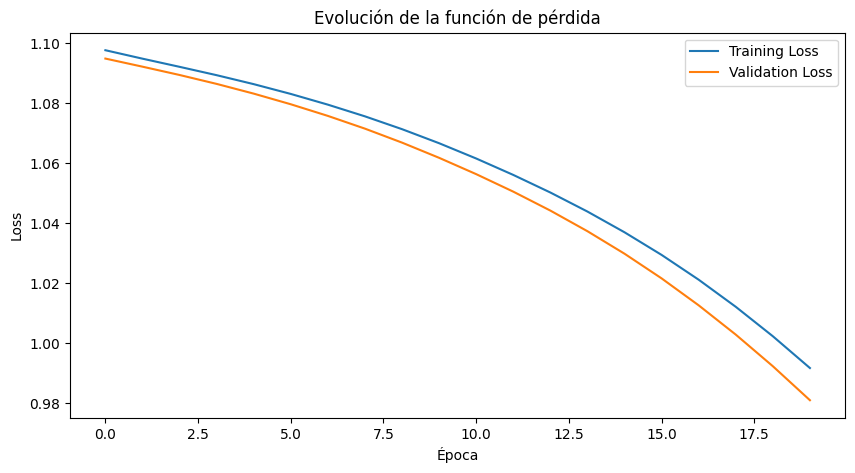

In [29]:
plt.figure(figsize=(10, 5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.title(
    "Evolución de la función de pérdida"
)

plt.xlabel("Época")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [30]:
print(
    f"Accuracy final de validación: {val_accuracies[-1]:.4f}"
)

Accuracy final de validación: 0.6472


# Conclusiones del checkpoint

A lo largo de las 20 épocas de entrenamiento se observa una disminución sostenida tanto de la pérdida de entrenamiento como de la pérdida de validación.

La evolución paralela de ambas curvas sugiere que el modelo logra aprender patrones presentes en las reseñas sin evidencias claras de sobreajuste durante esta primera etapa.

En términos de desempeño, el clasificador alcanzó una accuracy de validación cercana al 65%, demostrando que incluso una arquitectura sencilla basada en TF-IDF y una red neuronal multicapa es capaz de capturar información relevante para diferenciar opiniones positivas, neutras y negativas.

Más allá del resultado obtenido, el principal logro de este checkpoint consiste en disponer de una infraestructura completamente funcional de entrenamiento, validación y seguimiento de métricas que servirá como base para las próximas iteraciones del proyecto.

Las siguientes etapas incorporarán técnicas específicas de Procesamiento de Lenguaje Natural orientadas a mejorar la representación semántica de las reseñas y aumentar la capacidad predictiva del sistema.